# Notebook 1: Exploring ZTF Catalogs

## What is ZTF?

The **Zwicky Transient Facility (ZTF)** is a wide-field astronomical survey that scans the entire northern sky every few nights using a camera mounted on the 48-inch Samuel Oschin Telescope at Palomar Observatory in California. ZTF observes in three optical filters — **g** (green/blue), **r** (red), and **i** (near-infrared) — and produces *light curves* (brightness vs. time) for billions of sources.

## What are these catalogs?

We have pre-computed catalogs that contain the results of running **period-finding algorithms** on millions of ZTF light curves. The two algorithms are:

- **Lomb-Scargle (LS):** A generalized periodogram that finds periodic signals in unevenly-sampled data. It works well for smooth, sinusoidal-like variations (e.g., pulsating stars, ellipsoidal variables). The `significance` column measures how confident the algorithm is that the period is real.
- **Box Least Squares (BLS):** Optimized for detecting periodic *box-shaped* dips, like those caused by eclipses in binary star systems. The `bls_power` column plays the same role as LS significance. BLS also provides eclipse-specific measurements like depth, transit duration, and SNR.

Each catalog directory contains many `.result` files. Each row represents one source and includes its sky position, a candidate period, and various statistics.

In this notebook, you will learn how to load these catalogs, explore their contents, and filter them to find interesting candidates.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ztf_tools

## Choose your catalog

Pick which catalog to explore by setting `CATALOG` below. The rest of the notebook adapts automatically.

| Catalog | Best for | Power/significance column |
|---------|----------|--------------------|
| `'ls'` | Smooth variability (pulsations, ellipsoidal) | `significance` |
| `'bls'` | Sharp eclipses (eclipsing binaries, transits) | `bls_power` |

In [2]:
CATALOG = 'bls'  # <-- change to 'ls' or 'bls'

catalog_dirs = {
    'ls':  '/ztf/catalogs/lomb_scargle',
    'bls': '/ztf/catalogs/box_least_squares',
}
catalog_dir = catalog_dirs[CATALOG]
print(f'Using catalog: {CATALOG} ({catalog_dir})')

Using catalog: bls (/ztf/catalogs/box_least_squares)


## Loading a single `.result` file

Let's start by looking at what a single `.result` file looks like. The files are whitespace-delimited tables with no header row.

**Lomb-Scargle columns (13):**

| # | Name | Description |
|---|------|-------------|
| 0 | `ra` | Right ascension (deg) |
| 1 | `dec` | Declination (deg) |
| 2 | `ps_id` | Pan-STARRS source ID |
| 3 | `period` | Best-fit period (days) |
| 4 | `significance` | LS significance of best period |
| 5 | `significance_half` | Significance at half the best period |
| 6 | `significance_twice` | Significance at twice the best period |
| 7 | `mad` | Median absolute deviation (calibrated) |
| 8 | `variance` | Variance (calibrated) |
| 9 | `skew` | Skewness |
| 10 | `kurtosis` | Kurtosis |
| 11 | `ref_flux_flag` | Reference flux flag |
| 12 | `ref_flux` | Reference flux |

**BLS columns (24):**

| # | Name | Description |
|---|------|-------------|
| 0 | `ra` | Right ascension (deg) |
| 1 | `dec` | Declination (deg) |
| 2 | `ps_id` | Pan-STARRS source ID |
| 3 | `period` | Best-fit period (days) |
| 4 | `bls_power` | BLS power (significance) |
| 5–6 | `depth`, `depth_err` | Eclipse depth and error |
| 7–8 | `depth_odd`, `depth_odd_err` | Odd-eclipse depth |
| 9–10 | `depth_even`, `depth_even_err` | Even-eclipse depth |
| 11–12 | `depth_half`, `depth_half_err` | Half-period depth |
| 13–14 | `depth_phased`, `depth_phased_err` | Phased depth |
| 15 | `harmonic_amplitude` | Harmonic amplitude |
| 16 | `harmonic_delta_logL` | Harmonic log-likelihood difference |
| 17 | `n_transits` | Number of transits observed |
| 18 | `n_points_transit` | Data points in transit |
| 19 | `transit_duration` | Transit duration (days) |
| 20 | `mid_transit_time` | Mid-transit time (JD) |
| 21 | `out_of_eclipse_scatter` | Out-of-eclipse scatter |
| 22 | `snr` | Signal-to-noise ratio |
| 23 | `min_time` | Minimum time |

`ztf_tools.load_catalog()` auto-detects the column schema based on the number of columns.

In [3]:
import glob, os

result_files = sorted(glob.glob(os.path.join(catalog_dir, '*.result')))
print(f'Found {len(result_files):,} .result files in {CATALOG} catalog')

Found 41,098 .result files in bls catalog


In [4]:
# Load a single file to see the raw data
one_file = ztf_tools.load_catalog(catalog_dir, max_files=1)
print(f'Columns: {list(one_file.columns)}')
one_file.head(10)

Columns: ['ra', 'dec', 'ps_id', 'period', 'bls_power', 'depth', 'depth_err', 'depth_odd', 'depth_odd_err', 'depth_even', 'depth_even_err', 'depth_half', 'depth_half_err', 'depth_phased', 'depth_phased_err', 'harmonic_amplitude', 'harmonic_delta_logL', 'n_transits', 'n_points_transit', 'transit_duration', 'mid_transit_time', 'out_of_eclipse_scatter', 'snr', 'min_time']


,ra,dec,ps_id,period,bls_power,depth,depth_err,depth_odd,depth_odd_err,depth_even,...,depth_phased_err,harmonic_amplitude,harmonic_delta_logL,n_transits,n_points_transit,transit_duration,mid_transit_time,out_of_eclipse_scatter,snr,min_time
0,57.415668,-14.205728,90950574157293526,0.025744,10.874882,-23.547772,3.494966,-20.229283,4.321848,-28.463954,...,4.031195,8.257738,-14.433241,62411,87,0.004577,2.459100e+06,45.308861,-0.519717,-764.131291
1,57.426373,-14.204264,90950574263755305,0.041938,9.694141,26.952558,3.894798,32.132469,5.005979,20.356760,...,4.473048,8.104296,-16.065009,39337,70,0.006180,2.459100e+06,46.375851,0.581177,-764.131291
2,57.439919,-14.208028,90950574397971017,0.003553,13.142613,27.477423,3.840193,26.200468,5.562300,28.448309,...,3.793715,8.657030,-16.331193,455261,73,0.000593,2.459100e+06,42.042290,0.653566,-764.131291
3,57.440601,-14.209781,90940574406638574,0.048677,10.676449,32.240174,4.498836,26.093149,7.558515,35.222041,...,4.076282,8.964356,-16.163193,31779,53,0.007329,2.459100e+06,49.146271,0.656004,-764.131291
4,57.443218,-14.210019,90940574432118366,0.077405,12.583430,327.235434,10.969722,383.420923,14.439020,265.239641,...,10.883951,116.769850,-269.837144,20900,94,0.016739,2.459100e+06,408.530273,0.801007,-764.131291
5,57.449635,-14.206492,90950574496272595,0.022437,10.211147,28.546294,3.941688,30.791756,5.398183,26.394728,...,3.765111,7.206049,-20.375482,71428,66,0.003738,2.459100e+06,45.100407,0.632950,-764.131291
6,57.456631,-14.210639,90940574566037640,0.003775,9.835607,48.954712,7.554175,46.056936,9.761173,53.087201,...,5.549930,7.362633,-15.619158,421040,31,0.000275,2.459100e+06,46.492191,1.052966,-755.149368
7,57.462673,-14.208920,90940574626659665,0.006332,10.535553,-25.957438,3.288743,-29.412534,4.061825,-21.137199,...,3.570933,12.054992,-13.071421,251524,103,0.001521,2.459100e+06,46.183533,-0.562050,-764.131291
8,57.457130,-14.204925,90950574570634314,0.016766,10.340427,-30.731826,4.321679,-24.859985,5.472122,-38.961453,...,4.196307,8.459609,-18.309899,96190,71,0.003142,2.459100e+06,48.278145,-0.636558,-764.131291
9,57.457127,-14.204943,90950574571064890,0.019776,10.422775,-30.621404,4.308087,-23.054884,5.440307,-41.362357,...,4.676417,9.933132,-15.467264,83421,63,0.002851,2.459100e+06,49.778389,-0.615155,-764.131291


## Loading a sample of the catalog

Each catalog has ~59,000 `.result` files with hundreds of millions of rows — far too large to load into memory at once. Instead, we use `max_files` to load a **random sample** of files. 200 files is enough for representative distributions while staying fast (takes ~30s).

In [5]:
catalog = ztf_tools.load_catalog(catalog_dir, max_files=200)
print(f'Catalog shape: {catalog.shape}')
print(f'That\'s {catalog.shape[0]:,} sources (sampled from 200 files)')

Catalog shape: (5879432, 24)
That's 5,879,432 sources (sampled from 200 files)


In [6]:
catalog.describe()

/home/echickle/miniforge3/envs/ztf-example/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/echickle/miniforge3/envs/ztf-example/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/echickle/miniforge3/envs/ztf-example/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/echickle/miniforge3/envs/ztf-example/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,ra,dec,ps_id,period,bls_power,depth,depth_err,depth_odd,depth_odd_err,depth_even,...,depth_phased_err,harmonic_amplitude,harmonic_delta_logL,n_transits,n_points_transit,transit_duration,mid_transit_time,out_of_eclipse_scatter,snr,min_time
count,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,...,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06,5.879432e+06
mean,2.179815e+02,2.025087e+01,1.322988e+17,4.924674e+01,1.455010e+01,4.074236e+01,4.527375e+00,3.747078e+01,inf,3.634668e+01,...,inf,2.235584e+01,-2.455013e+03,1.311787e+05,1.836725e+02,1.130301e+01,2.459039e+06,6.741092e+01,3.547867e-01,-7.798112e+02
std,1.081650e+02,2.835026e+01,3.402037e+16,1.277077e+02,8.011184e+00,8.874491e+02,4.954589e+00,7.297185e+02,NaN,8.490161e+02,...,NaN,2.844576e+02,4.238702e+05,1.781328e+05,1.733537e+02,3.218384e+01,1.774851e+02,2.904722e+02,1.651037e+00,1.794422e+02
min,3.064199e+00,-2.796893e+01,7.443205e+16,2.777778e-03,2.383062e-02,-1.841249e+05,2.721200e-01,-1.693720e+05,2.726800e-01,-2.719670e+05,...,5.543551e-01,4.192420e-04,-6.426673e+08,1.000000e+00,1.000000e+00,1.242516e-04,2.458677e+06,0.000000e+00,-7.685039e+02,-1.281842e+03
25%,1.081492e+02,-6.332760e+00,1.004003e+17,7.228533e-03,1.098954e+01,-1.813698e+01,2.104459e+00,-1.725997e+01,2.865666e+00,-1.761552e+01,...,2.452801e+00,4.110931e+00,-2.652875e+01,1.196000e+03,4.700000e+01,8.859413e-04,2.458892e+06,3.806601e+01,-4.285134e-01,-9.089906e+02
50%,2.711151e+02,1.641103e+01,1.276928e+17,5.294670e-02,1.209336e+01,1.509409e+01,3.022889e+00,1.400719e+01,4.355135e+00,1.416352e+01,...,3.472665e+00,6.643322e+00,-1.699425e+01,2.806400e+04,1.350000e+02,4.425453e-03,2.459055e+06,4.222159e+01,3.753758e-01,-7.874994e+02
75%,3.013078e+02,4.629120e+01,1.635532e+17,1.307205e+00,1.492620e+01,3.131020e+01,4.998789e+00,2.981718e+01,7.617743e+00,2.999589e+01,...,5.479256e+00,1.204383e+01,-9.974380e+00,2.205132e+05,2.650000e+02,1.468106e-01,2.459154e+06,4.787659e+01,7.007327e-01,-6.081808e+02
max,3.591402e+02,8.362912e+01,2.083506e+17,4.912500e+02,4.153249e+02,2.591805e+05,2.110574e+02,2.566951e+05,inf,2.640051e+05,...,inf,2.015547e+05,1.135455e+08,7.031500e+05,1.439000e+03,1.500545e+02,2.459948e+06,1.126528e+05,3.199612e+02,1.266226e+02


## Exploring the distributions

Let's plot histograms of the two most important columns — **period** and **significance/power** — to get a feel for the data.

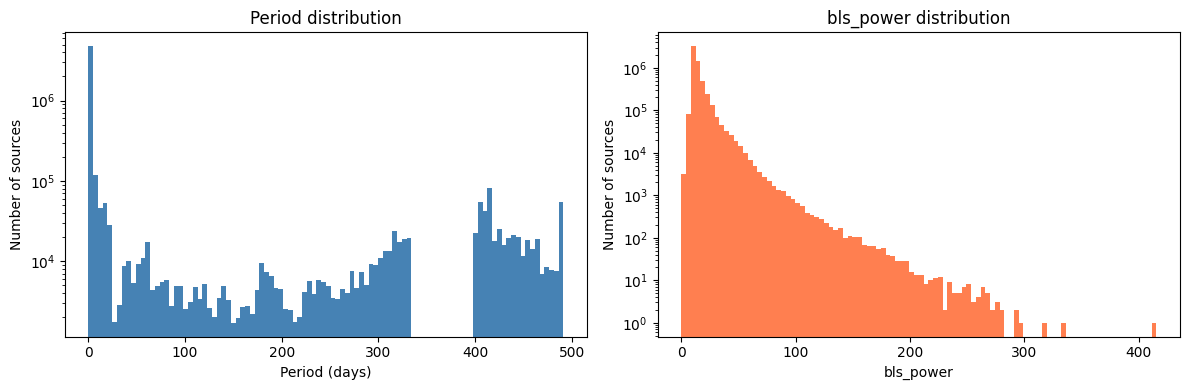

In [7]:
# Detect which column holds the significance/power
sig_col = 'significance' if 'significance' in catalog.columns else 'bls_power'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(catalog['period'], bins=100, color='steelblue', edgecolor='none')
ax1.set_xlabel('Period (days)')
ax1.set_ylabel('Number of sources')
ax1.set_title('Period distribution')
ax1.set_yscale('log')

ax2.hist(catalog[sig_col], bins=100, color='coral', edgecolor='none')
ax2.set_xlabel(sig_col)
ax2.set_ylabel('Number of sources')
ax2.set_title(f'{sig_col} distribution')
ax2.set_yscale('log')

fig.tight_layout()
plt.show()

Notice how most sources cluster at low significance — these are likely noise or spurious detections. The tail at high values is where the truly periodic objects live.

Because we loaded a random sample of files, these histograms are representative of the full catalog — the distributions look the same, just scaled down.

## Filtering for interesting candidates

We can use `ztf_tools.filter_candidates()` to apply cuts on significance/power and period. This works automatically with both LS and BLS catalogs. Let's apply some default cuts:
- **significance/power > 50** — only keep the most confident detections
- **period < 180/1440 days** (3 hours) — we're looking for short-period objects like compact binaries and pulsating white dwarfs

Since we're working with a sample, the candidate counts are proportionally smaller than the full catalog. To find more candidates, increase `max_files` above.

In [8]:
candidates = ztf_tools.filter_candidates(
    catalog, min_significance=50, max_period=180/1440
)
print(f'Candidates after cuts: {len(candidates):,} out of {len(catalog):,}')

Candidates after cuts: 329 out of 5,879,432


Let's see how the number of candidates changes with different thresholds:

In [9]:
for sig_cut in [10, 25, 50, 100, 200]:
    n = len(ztf_tools.filter_candidates(
        catalog, min_significance=sig_cut, max_period=180/1440
    ))
    print(f'  {sig_col} > {sig_cut:>4d}  \u2192  {n:>6,} candidates')

  bls_power >   10  →  2,898,396 candidates
  bls_power >   25  →   4,403 candidates
  bls_power >   50  →     329 candidates
  bls_power >  100  →      71 candidates
  bls_power >  200  →       4 candidates


## BLS-specific columns

If you're using the BLS catalog, there are extra columns that are very useful for vetting candidates. For example:
- **`depth`** and **`snr`** — How deep is the eclipse and how significant?
- **`depth_odd`** vs. **`depth_even`** — Are alternating eclipses the same depth? If not, the "period" might actually be half the true orbital period.
- **`n_transits`** — How many eclipses were observed? More transits = more reliable.
- **`transit_duration`** — How long is the eclipse? Very short durations at short periods suggest compact objects.

*(If you're using the LS catalog, the cell below will be skipped.)*

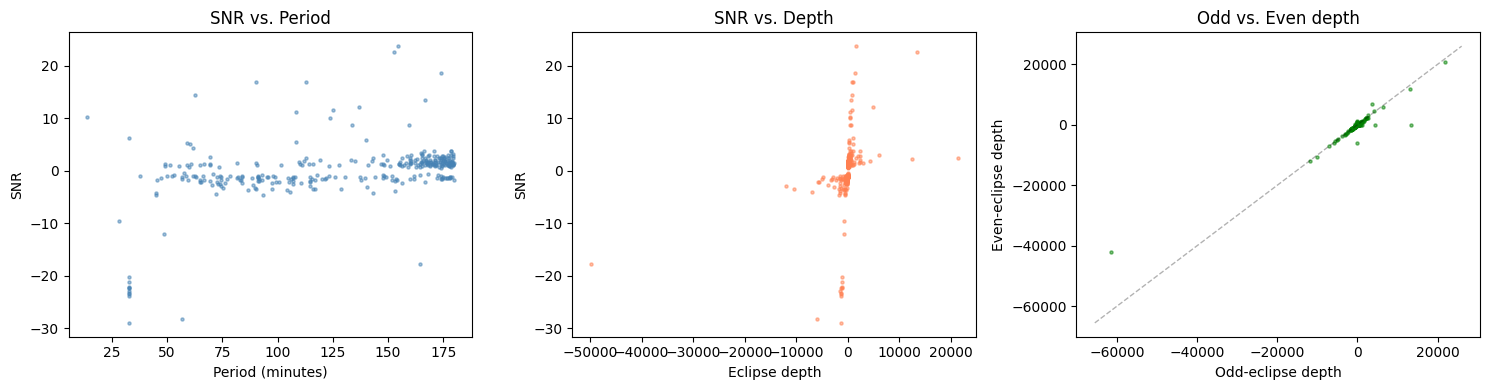

In [10]:
if CATALOG == 'bls' and len(candidates) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(candidates['period'] * 1440, candidates['snr'],
                    s=5, alpha=0.5, color='steelblue')
    axes[0].set_xlabel('Period (minutes)')
    axes[0].set_ylabel('SNR')
    axes[0].set_title('SNR vs. Period')

    axes[1].scatter(candidates['depth'], candidates['snr'],
                    s=5, alpha=0.5, color='coral')
    axes[1].set_xlabel('Eclipse depth')
    axes[1].set_ylabel('SNR')
    axes[1].set_title('SNR vs. Depth')

    # Odd vs even depth — points far from the 1:1 line may be at half the true period
    axes[2].scatter(candidates['depth_odd'], candidates['depth_even'],
                    s=5, alpha=0.5, color='green')
    lims = [min(axes[2].get_xlim()[0], axes[2].get_ylim()[0]),
            max(axes[2].get_xlim()[1], axes[2].get_ylim()[1])]
    axes[2].plot(lims, lims, 'k--', alpha=0.3, lw=1)
    axes[2].set_xlabel('Odd-eclipse depth')
    axes[2].set_ylabel('Even-eclipse depth')
    axes[2].set_title('Odd vs. Even depth')

    fig.tight_layout()
    plt.show()
elif CATALOG == 'ls':
    print('(BLS-specific plots skipped — switch CATALOG to "bls" to see them)')

## Sky map of candidates

Let's see where our filtered candidates are on the sky using an **Aitoff projection** — a common way to display all-sky maps in astronomy. We convert RA from (0°, 360°) to (−180°, +180°) and both coordinates to radians.

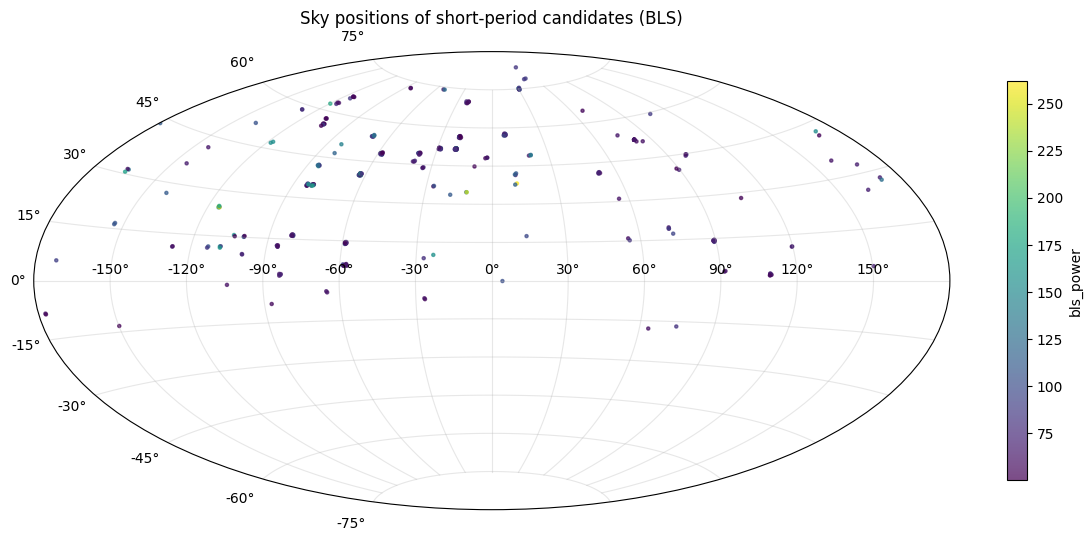

In [11]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': 'aitoff'})

ra_plot = np.deg2rad(candidates['ra'].values - 360 * (candidates['ra'].values > 180))
dec_plot = np.deg2rad(candidates['dec'].values)

sc = ax.scatter(
    ra_plot, dec_plot,
    c=candidates[sig_col],
    s=5, cmap='viridis', alpha=0.7
)
plt.colorbar(sc, label=sig_col, shrink=0.7)
ax.set_title(f'Sky positions of short-period candidates ({CATALOG.upper()})', pad=20)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## A note on harmonics

Both LS and BLS can recover **harmonics** of the true orbital period. For example, an eclipsing binary with two eclipses per orbit (a primary and a secondary) is often detected at **half** the true period. This is especially common with BLS.

The LS catalog helpfully includes `significance_half` and `significance_twice` columns, which tell you how significant the signal is at half and twice the best period. If `significance_half` is comparable to `significance`, the true period might be double what's listed.

For BLS, comparing `depth_odd` and `depth_even` serves a similar purpose — if the alternating eclipses have very different depths, you're probably looking at half the true orbital period (one deep primary eclipse and one shallow secondary).

When you phase-fold a candidate (Notebook 2), always check whether doubling the period gives a better-looking light curve!

## Summary

In this notebook you learned how to:

1. **Load** ZTF period-finding catalogs (LS or BLS) into pandas DataFrames
2. **Explore** the distributions of periods and significance/power
3. **Filter** the catalog to select promising variable star candidates
4. **Inspect** BLS-specific diagnostics (depth, SNR, odd/even eclipses)
5. **Visualize** candidate positions on the sky

Try re-running this notebook with the other catalog (`'ls'` vs `'bls'`) to see how the results differ!

Now head to **Notebook 2 (`02_plotting_lightcurves.ipynb`)** to extract and plot actual light curves from the ZTF matchfiles.